# 1. Setup

### Imports

In [1]:
# reload new modules automatically
%load_ext autoreload
%autoreload 2

In [2]:
try:
    from egrabber import *
except:
    print('Egrabber not found, continuing without it.')
import numpy as np
import time
import cv2
import ctypes
# from tqdm import tqdm
import winsound
import warnings
from datetime import datetime
import math
from scipy.signal import butter, filtfilt,resample
from scipy.io.wavfile import write

# Add parent directory to path for local imports
import sys
from pathlib import Path
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

# local imports
from utils.recover_core_lib import *

SWP_NOMOVE = 0x0002
SWP_NOSIZE = 0x0001
HWND_TOPMOST = -1

import traceback

import matplotlib.pyplot as plt

from threading import Thread
import os

signal_crop = None
if 'run_opt' not in locals():
    run_opt = {}

if 'run_opt_recovery' not in locals():
    run_opt_recovery = {}

# enable interactive matplotlib plots
%matplotlib inline

FONT = cv2.FONT_HERSHEY_SIMPLEX

from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

### Laser Camera Parameters

In [60]:
# setup laser camera parameters
N_ROI_ROWS = 10 # rows
N_ROI_COLUMNS = 10 # columns
ROI_ROW_HEIGHT = 30 # row height
ROI_COLUMN_WIDTH = 70 # column width

# calibrate on a smaller ROI with lower FPS
CALIBRATION_FPS = 500
CALIBRATION_EXPOSURE = 60
CALIBRATION_GAIN = 1

FPS = 2_500
EXPOSURE = 60
GAIN = 1

BUFFER_PART_COUNT = 1625 # makes it faster to capture/send frames

### Overhead Camera Parameters

In [4]:
EXPOSURE_MS = 8        # Exposure time in milliseconds
FRAME_RATE = 30          # Target frame rate (FPS)
PIXEL_CLOCK = 86         # Pixel clock speed
CAMERA_GAIN = 0          # Camera gain (0-100) higher gain = brighter image
RESIZE_FACTOR = 0.75     # Preview resize factor for display
GAMMA = 2              # Gamma correction for preview

### Vibration Recording Parameters

In [5]:
AUDIO_DIR = Path(r'C:\Users\eitanturok\good-vibrations\data\audio\chirp_50_1000_3.0sec')
N_CAPTURE_SECONDS   = 3.1  # Duration of capture in seconds

### Other Parameters

In [6]:
PREVIEW = 1 # set higher values for more debug info

In [7]:
RESET_ROIS = True  # Whether to reset ROIs or use previous ones

# 2. Setup Overhead Camera

In [8]:
import sys
from pathlib import Path

# Add parent directory to path for utils imports
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from pyueye import ueye
from utils.ids_camera.pyueye_example_camera import Camera as PyueyeCamera
from utils.image_processing import adjustGamma

In [9]:
def setup_camera(exposure_ms=3.0, frame_rate=30, pixel_clock=86, gain=0):
    """
    Initialize and configure IDS camera with specified parameters.

    Args:
        exposure_ms: Exposure time in milliseconds
        frame_rate: Target frame rate in FPS
        pixel_clock: Pixel clock speed
        gain: Camera gain (0-100)

    Returns:
        overhead_cam: Configured Camera object
        img_size: Tuple of (width, height)
    """

    # Check if cam exists in the local namespace and close it
    # Simply calling `del cam` will fail because Python's garbage collector doesn't necessarily close the hardware driver connection immediately, leaving the camera locked.
    global overhead_cam
    if 'overhead_cam' in locals() or 'overhead_cam' in globals():
        try:
            overhead_cam.exit()
            print("Closed existing camera connection.")
        except:
            pass

    # Initialize camera
    overhead_cam = PyueyeCamera(device_id=0)
    overhead_cam.init()
    overhead_cam.set_colormode(ueye.IS_CM_SENSOR_RAW8)
    overhead_cam.alloc(buffer_count=40)

    # Set camera parameters (set_frame_rate returns the actual frame rate)
    overhead_cam.set_pixel_clock(pixel_clock)
    overhead_cam.set_exposure(exposure_ms)
    overhead_cam.set_gain(gain)
    actual_fps = overhead_cam.set_frame_rate(frame_rate)

    # Get actual settings and image size
    actual_exposure = overhead_cam.get_exposure()
    actual_pixel_clock = overhead_cam.get_pixel_clock()
    actual_gain = overhead_cam.get_gain()
    img_w = overhead_cam.get_aoi().width
    img_h = overhead_cam.get_aoi().height

    print('===== Camera Setup =====')
    print(f'Image size: {img_w}x{img_h}')
    print(f'Exposure: {actual_exposure:.3f} ms')
    print(f'Frame rate: {actual_fps:.3f} FPS')
    print(f'Pixel clock: {actual_pixel_clock} MHz')
    print(f'Gain: {actual_gain}')

    return overhead_cam, (img_w, img_h)

In [10]:
def preview_image(overhead_cam, resize_factor=0.75, gamma=1.0):
    """
    Display live camera preview. Press Enter to exit.

    Args:
        overhead_cam: Camera object
        resize_factor: Scale factor for display (0-1)
        gamma: Gamma correction value
    """
    # Start video capture
    overhead_cam.disable_external_trigger()
    overhead_cam.capture_video()

    cv2.namedWindow("IDS Camera Preview")

    try:
        while True:
            # Capture raw frame
            raw_frame, _ = overhead_cam.read_frame()

            # Convert Bayer to BGR FIRST (before rotation to preserve Bayer pattern)
            frame = cv2.cvtColor(raw_frame.astype('uint8'), cv2.COLOR_BAYER_BG2BGR)

            # Rotate 180 degrees to fix camera orientation
            frame = cv2.rotate(frame, cv2.ROTATE_180)

            # Apply gamma correction (adjustGamma is imported at top)
            if gamma != 1.0:
                frame = adjustGamma(frame, gamma=gamma)

            # Resize for display
            if resize_factor != 1:
                frame = cv2.resize(frame, None, fx=resize_factor, fy=resize_factor)

            # Add info text
            cv2.putText(frame, 'Press Enter to exit', (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            cv2.imshow("IDS Camera Preview", frame)

            # Exit on Enter key
            if cv2.waitKey(1) == 13:
                break

    finally:
        cv2.destroyAllWindows()
        overhead_cam.stop_video()

In [11]:
def capture_image(overhead_cam):
    # Start video capture mode
    overhead_cam.disable_external_trigger()
    overhead_cam.capture_video()

    # Capture single frame
    raw_frame, timestamp = overhead_cam.read_frame()

    # Stop capture
    overhead_cam.stop_video()

    # Convert to color FIRST (before rotation to preserve Bayer pattern)
    color_image = cv2.cvtColor(raw_frame.astype('uint8'), cv2.COLOR_BAYER_BG2BGR)

    # Rotate 180 degrees to fix camera orientation
    color_image = cv2.rotate(color_image, cv2.ROTATE_180)
    raw_frame = cv2.rotate(raw_frame, cv2.ROTATE_180)

    if PREVIEW >= 2:
        print(f'Image captured at {timestamp}')
        print(f'Shape: {color_image.shape}')

    return color_image, raw_frame

In [12]:
overhead_cam, img_size = setup_camera(exposure_ms=EXPOSURE_MS, frame_rate=FRAME_RATE, pixel_clock=PIXEL_CLOCK, gain=CAMERA_GAIN)

preview_image(overhead_cam, resize_factor=RESIZE_FACTOR, gamma=GAMMA)

===== Camera Setup =====
Image size: 2056x1542
Exposure: 7.998 ms
Frame rate: 29.999 FPS
Pixel clock: 237 MHz
Gain: 0


In [13]:
# 1. Call the function and unpack both returned images
color_img, raw_img = capture_image(overhead_cam)

success = cv2.imwrite(r'C:\Users\eitanturok\good-vibrations\assets\table.png', color_img)

# 3. Setup Laser Camera

## Init Laser Camera

In [14]:
class MikrotronCamera(object):

    def __init__(self, info_field=False, ):
        self.gentl   = EGenTL()
        self.grabber = EGrabber(self.gentl)
        # self.grabber.remote.set("CxpLinkConfiguration", "CXP12_X4")
        self.grabber.stream.set('BufferPartCount', 1)
        self.update_size()
        self.grabber.realloc_buffers(20)
        #self.grabber.start()

        self.info_field = info_field
        if self.info_field:
            self.grabber.remote.set("InfoFieldTimeStampEnable", True)
            self.grabber.remote.set("InfoFieldFrameCounterEnable", True)
            self.grabber.remote.set("InfoFieldRoiEnable", True)

    # def set_buffer_part_count(self, buffer_count):
    #     self.grabber.stream.set('BufferPartCount', buffer_count)
    #     self.grabber.realloc_buffers(20)

    def set_buffer_part_count(self, buffer_count):
        self.grabber.stop()
        self.grabber.stream.set('BufferPartCount', buffer_count)
        self.grabber.realloc_buffers(20)
        self.grabber.start()

    def get_exposure(self):
        return self.grabber.remote.get("ExposureTime")

    def set_exposure(self, exposure_value):
        self.grabber.remote.set("ExposureTime", exposure_value)

    def get_frame_rate(self):
        return self.grabber.remote.get("AcquisitionFrameRate")

    def set_frame_rate(self, frame_rate):
        self.grabber.remote.set("AcquisitionFrameRate", frame_rate)

    def get_max_frame_rate(self):
        return self.grabber.remote.get("AcquisitionFrameRateMax")

    def get_acquisition_mode(self):
        return self.grabber.remote.get("AcquisitionMode")

    def set_gain(self, gain_value):
        self.grabber.remote.set("Gain", gain_value)

    def start_acquisition(self):
        self.grabber.remote.set("AcquisitionMode", "Continuous")
        self.grabber.remote.execute("AcquisitionStart")
        while not self.grabber.remote.done("AcquisitionStart"):
            pass

    def stop_acquisition(self):
        self.grabber.remote.execute("AcquisitionStop")
        while not self.grabber.remote.done("AcquisitionStop"):
            pass

    def reset_buffer(self):
        self.update_size()
        self.grabber.stop()
        self.grabber.realloc_buffers(20)
        self.grabber.start()

    # ---------- global ROI -----------

    def get_global_roi(self):
        x = self.grabber.remote.get("OffsetX")
        w = self.grabber.remote.get("Width")
        y = self.grabber.remote.get("OffsetY")
        h = self.grabber.remote.get("Height")
        return (x, y, w, h)

    def reset_global_roi(self):
        self.grabber.stop()
        self.grabber.remote.set("MultiROILUTModeEn", False)
        self.grabber.remote.set("OffsetX", 0)
        self.grabber.remote.set("OffsetY", 0)
        self.grabber.remote.set("Width", 1920)
        self.grabber.remote.set("Height", 1080)
        self.reset_buffer()
        self.grabber.start()

    def set_global_roi(self, x, y, w, h):
        x1, y1, x2, y2 = x, y, x + w, y + h
        if w < 128 or w % 16 != 0 or w > 1920:
            raise Exception("Set Width has to be greater than 128 px, and incremented by 16")
        #if h < 8 or h % 4 != 0 or h > 1080:
        #    raise Exception("Set Height has to be greater than 8 px, and incremented by 8")
        if x % 16 != 0:
            raise Exception("Set OffsetX has to be greater than 16 px, and incremented by 16")
        if y % 4 != 0:
            raise Exception("Set OffsetY has to be greater than 8 px, and incremented by 4")

        if x1 < 0 or y1 < 0 or x2 > 1920 or y2 > 1080:
            raise Exception("ROI out of sensor limits!")

        ## this order matters, set the height to a smaller value first
        ## then it lets you set the offset
        self.grabber.remote.set("Width", w)
        self.grabber.remote.set("Height", h)
        self.grabber.remote.set("OffsetX", x)
        self.grabber.remote.set("OffsetY", y)

        self.reset_buffer()

    def set_global_roi_noy(self, x, y, w, h):
        x1, y1, x2, y2 = x, y, x + w, y + h
        if w < 128 or w % 16 != 0 or w > 1920:
            raise Exception("Set Width has to be greater than 128 px, and incremented by 16")
        #if h < 8 or h % 4 != 0 or h > 1080:
        #    raise Exception("Set Height has to be greater than 8 px, and incremented by 8")
        if x % 16 != 0:
            raise Exception("Set OffsetX has to be greater than 16 px, and incremented by 16")
        if y % 4 != 0:
            raise Exception("Set OffsetY has to be greater than 8 px, and incremented by 4")

        if x1 < 0 or y1 < 0 or x2 > 1920 or y2 > 1080:
            raise Exception("ROI out of sensor limits!")

        ## this order matters, set the height to a smaller value first
        ## then it lets you set the offset
        self.grabber.remote.set("Width", w)
        self.grabber.remote.set("Height", h)
        self.grabber.remote.set("OffsetX", x)

        self.reset_buffer()

    # ---------- rows -----------

    def set_rows(self, row_idxs):

        self.grabber.remote.set("MultiROILUTModeEn", False)
        H = len(row_idxs) * 2
        if H % 4 != 0:
            raise Exception("Set H is not a multiple of 4")

        for i, idx in enumerate(row_idxs):
            self.grabber.remote.set("MultiROILUTIndex", i)
            self.grabber.remote.set("MultiROILUTValue", int(idx))

        self.grabber.remote.set("Height", H)
        self.grabber.remote.set("MultiROILUTModeEn", True)
        self.reset_buffer()

    '''
    def set_rows_with_index(self, indexed_rows):

        self.grabber.remote.set("MultiROILUTModeEn", False)

        for idx, row in indexed_rows:
            self.grabber.remote.set("MultiROILUTIndex", idx)
            self.grabber.remote.set("MultiROILUTValue", int(row))

        self.grabber.remote.set("MultiROILUTModeEn", True)
        self.reset_buffer()

    def change_row(self, register_idx, row):
        self.grabber.remote.set("MultiROILUTIndex", register_idx)
        self.grabber.remote.set("MultiROILUTValue", row)

    def unset_rows(self):
        self.grabber.remote.set("MultiROILUTModeEn", False)
        for idx, row in enumerate(range(0, 540)):
            self.grabber.remote.set("MultiROILUTIndex", idx)
            self.grabber.remote.set("MultiROILUTIndex", 0)

        self.grabber.remote.set("Height", 1080)
        self.update_size()
    '''

    def update_size(self):
        self.w = self.grabber.stream.get('Width')
        self.h = self.grabber.stream.get('Height')

    def get_im_size(self):
        return self.w, self.h

def get_max_possible_exposure(fps):
    exp = (1000.0/fps) * 1000
    exp = int(exp) - 1
    return exp

'''New capture functions'''
class CaptureFrameThread2(Thread):
    def __init__(self, cam, N_frames, IMG_H, IMG_W):
        super(CaptureFrameThread2, self).__init__()
        self.cam      = cam
        self.frames_per_buffer = cam.grabber.stream.get('BufferPartCount')
        self.N_frames = int(np.ceil(N_frames/self.frames_per_buffer))
        self.w = cam.grabber.stream.get('Width')
        self.h = cam.grabber.stream.get('Height')
        self.h_roi = cam.get_global_roi()[-1]
        self.frames   = np.empty((self.N_frames, self.h, self.w), dtype=np.uint8)

    def __ptr_to_ndarray(self, ptr, w, size):
        data = ct.cast(ptr, ct.POINTER(ct.c_ubyte * size)).contents
        c = 1
        return np.frombuffer(data, count=size, dtype=np.uint8).reshape((-1, w))

    def run(self):
        for i in range(self.N_frames):
            with Buffer(self.cam.grabber, timeout=5000) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                delivered  = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                proc = 0
                while proc < delivered:
                    imagePtr = buffer_ptr + proc * image_size
                    img = self.__ptr_to_ndarray(imagePtr, self.cam.w, image_size)
                    self.frames[i,proc*self.h_roi:(proc+1)*self.h_roi] = img.copy()
                    proc = proc + 1
    def read(self):
        video = self.frames.reshape(self.N_frames * self.frames_per_buffer, self.h_roi, self.w)
        return video, None

class CaptureFrameThread(Thread):
    def __init__(self, cam, N_frames, IMG_H, IMG_W, copy=True):
        super(CaptureFrameThread, self).__init__()
        self.cam = cam
        self.N_frames = N_frames
        self.copy = copy
        self.frames = np.empty((N_frames, IMG_H, IMG_W), dtype=np.uint8)
        self.timestamps = np.empty((N_frames,), dtype=np.int64)
        self.frame_counter = 0

    def __ptr_to_ndarray(self, ptr, w, size):
        data = ct.cast(ptr, ct.POINTER(ct.c_ubyte * size)).contents
        c = 1
        return np.frombuffer(data, count=size, dtype=np.uint8).reshape((-1, w))

    def run(self):
        for i in range(self.N_frames):
            with Buffer(self.cam.grabber, timeout=500) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                img = self.__ptr_to_ndarray(buffer_ptr, self.cam.w, image_size)
                ts = time.perf_counter_ns() // 1000000
                self.frames[i] = img.copy()
                self.timestamps[i] = ts
                self.frame_counter = (self.frame_counter + 1) % 256
    def read(self):
        return self.frames, self.timestamps

def capture_N_frames(cam, N_frames, IMG_H, IMG_W, dtype=np.uint8):
    cam.grabber.flush_buffers()
    cam.grabber.start()
    thread = CaptureFrameThread2(cam, N_frames, IMG_H, IMG_W)
    thread.start()
    thread.join()
    frames, timestamps = thread.read()
    cam.grabber.stop()
    cam.grabber.flush_buffers()
    return frames, timestamps

def save_data(all_data, N, fps, flag="custom_rows", prefix="frame", unshuffle=False, row_manip=None):
    os.makedirs(f"output/{flag}_{fps}", exist_ok=True)
    for i in range(N):
        img = all_data[i, :, :]
        if unshuffle:
            img = row_manip.unshuffle_camera_rows(img)
        img = cv2.cvtColor(img, cv2.COLOR_BayerGRBG2BGR)
        cv2.imwrite(f"output/{flag}_{fps}/{prefix}.{i}.jpg", img)
        # exit()

def create_hann_window(image_shape,margin,dtype =cv2.CV_32F):
    def pad_image(image, h_pad, v_pad):
        padded_image = cv2.copyMakeBorder(image, v_pad, v_pad, h_pad, h_pad, cv2.BORDER_CONSTANT, value=[0, 0, 0])
        return padded_image

    h,w  = image_shape
    hannW = cv2.createHanningWindow((w - 2*margin, h - 2*margin), dtype)
    hannW = pad_image(hannW,margin,margin)
    return hannW

def stretch_contrast(image,minmax=None):
    if minmax is None:
        min_val = np.min(image)
        max_val = np.max(image)
    else:
        min_val,max_val = minmax
    stretched = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    return stretched

def select_rectangle(image):
    rect_coords = cv2.selectROI("Image", image, fromCenter=False, showCrosshair=True)

    # Close the window
    cv2.destroyAllWindows()

    # Return the rectangle image_showcoordinates
    return rect_coords

In [15]:
cam = MikrotronCamera(info_field=False)
run_opt['cam_params'] = {}

## Preview Laser Camera

In [16]:
class FramePreviewThread(Thread):
    def __init__(self, cam, show_full_frame=True):

        super(FramePreviewThread, self).__init__()
        self.cam = cam
        self.running = True

        self.w = cam.grabber.stream.get('Width')
        self.h = cam.grabber.stream.get('Height')
        self.h_roi = cam.get_global_roi()[-1]
        self.show_full_frame = show_full_frame

        if self.show_full_frame:
            self.frame = np.zeros((self.h,self.w,1),dtype='uint8')
        else:
            self.frame = np.zeros((self.h_roi,self.w,1),dtype='uint8')
        self.frame_counter = 0

    def __ptr_to_ndarray(self, ptr, w, size):
        data = ct.cast(ptr, ct.POINTER(ct.c_ubyte * size)).contents
        c = 1
        return np.frombuffer(data, count=size, dtype=np.uint8).reshape((-1,w))

    def run(self):
        while self.running:
            with Buffer(self.cam.grabber, timeout=5000) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                delivered  = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                proc = 0
                while proc < delivered:
                    imagePtr = buffer_ptr + proc * image_size
                    img = self.__ptr_to_ndarray(imagePtr, self.cam.w, image_size)
                    if self.show_full_frame:
                        self.frame[proc*self.h_roi:(proc+1)*self.h_roi,:,0] = img.copy()
                    else:
                        self.frame = img
                    proc = proc + 1
                    self.frame_counter =  (self.frame_counter + 1) % 256

    def read(self):
        return self.frame, self.frame_counter

    def stop(self):
        self.running = False

show_full_frame = 0

def preview_camera(cam, resize_factor = 1, gamma_val=2, is_strech_contrast=0,use_crop = None,
                   show_full_frame=True):

    try:
        #cam.stop_acquisition()
        cam.grabber.start()
        #cam.start_acquisition()
        thread = FramePreviewThread(cam,show_full_frame=show_full_frame)
        thread.start()
        cv2.namedWindow("frame")

        # Get the window handle for the OpenCV window
        hwnd = ctypes.windll.user32.FindWindowW(None, "frame")

        prev_time = time.time()
        fps = 0

        while(True):

            frame,thread_counter = thread.read()

            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

            if use_crop is not None:
                frame = frame[:,use_crop[0]:use_crop[1]]

            if resize_factor!=1:
                frame = cv2.resize(frame,None,fx = resize_factor, fy = resize_factor)

            # Calculate FPS
            #curr_time = time.time()
            #time_diff = curr_time - prev_time
            #fps = 1 / (time_diff + 1e-12)
            #prev_time = curr_time

            # Add FPS to the frame

            if is_strech_contrast:
                frame_show = stretch_contrast(frame)
            else:
                frame_show = frame

            cv2.putText(frame,'cam',(30,30), FONT, 0.75,(255,255,255),2,cv2.LINE_AA)

            #fps_text = f'FPS: {fps:.2f}'
            #cv2.putText(frame_show, fps_text, (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)


            cv2.imshow("frame",frame_show)

            # Bring the window to the front
            ctypes.windll.user32.SetWindowPos(hwnd, HWND_TOPMOST, 0, 0, 0, 0, SWP_NOMOVE | SWP_NOSIZE)

            key = cv2.waitKeyEx(1)
            if key==13:
                break
            elif key==32: #space
                pass
            if key==40: # "( key"
                gamma_val-= 0.1
            if key==41: # ") key"
                gamma_val+= 0.1

    except Exception:
        traceback.print_exc()
        print('Closing camera thread.')

    # cleanup
    cv2.destroyAllWindows()
    thread.stop()
    thread.join()
    #cam.stop_acquisition()
    cam.grabber.stop()
    cam.grabber.flush_buffers()

The preview appears in a popup window. Click enter to exit.

In [17]:
preview_camera(cam,resize_factor=1,gamma_val=2.5,use_crop = None,show_full_frame=show_full_frame,is_strech_contrast=1)

## Set low frame rate for calibration

In [18]:
if RESET_ROIS:
    run_opt['cam_params']['camera_FPS'] = CALIBRATION_FPS
    run_opt['cam_params']['exposure']   = CALIBRATION_EXPOSURE
    run_opt['cam_params']['gain']   = CALIBRATION_GAIN

    cam.set_frame_rate(run_opt['cam_params']['camera_FPS'])
    cam.set_exposure(run_opt['cam_params']['exposure'])
    cam.set_gain(run_opt['cam_params']['gain'])

    print(f'ROI = {cam.get_global_roi()}')
    print('Image height = {:} [px]'.format(cam.grabber.stream.get('Height')))
    print(f'frame rate  = {cam.get_frame_rate()} [FPS]')
    print(f'exposure  = {cam.get_exposure()} [us]')
    print(f'max frame rate = {cam.get_max_frame_rate()} [Hz]')

    cam.set_buffer_part_count(1)
    if 1:
        run_opt['cam_params']['get_global_roi'] = cam.get_global_roi()
        run_opt['cam_params']['get_frame_rate'] = cam.get_frame_rate()
        run_opt['cam_params']['get_max_frame_rate'] = cam.get_max_frame_rate()
        run_opt['cam_params']['get_exposure'] = cam.get_exposure()

ROI = (432, 0, 1040, 300)
Image height = 300 [px]
frame rate  = 500 [FPS]
exposure  = 60 [us]
max frame rate = 7287 [Hz]


## Reset ROIs

At this point, the laser should be turned on!

In [19]:
if RESET_ROIS:
    cam.reset_global_roi()
    print('We reset the ROIs')

We reset the ROIs


## Set the ROIs

In [20]:
run_opt_multiROIs = {}
run_opt_multiROIs['N_ROIs'] = N_ROI_ROWS

[(521, 95), (811, 195), (811, 302), (813, 400), (917, 484), (918, 611), (908, 697), (909, 796), (911, 891), (902, 1003)]
[(437, 945), (1477, 889)]


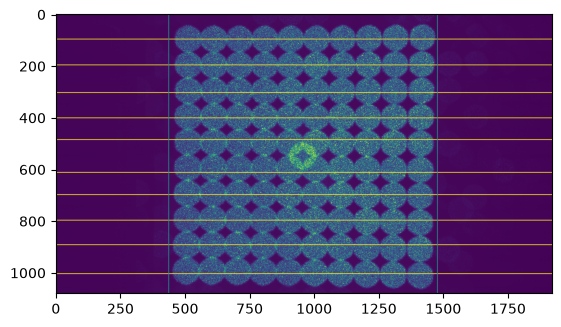

In [21]:
if RESET_ROIS:

    frame_recording, times = capture_N_frames(cam, 10, *cam.get_im_size()[::-1]) # todo: should this 10 also be N_ROIs?

    def select_points_horiz(event, x, y, flags, param):
        global points, num_points

        # On left mouse button click
        if event == cv2.EVENT_LBUTTONDOWN:
            # Store the point
            points.append((x, y))

            # Draw a horizontal line across the row of the clicked point
            cv2.line(image, (0, y), (image.shape[1], y), 255, 2)
            cv2.imshow("Image", image)
            num_points += 1

            # If we have reached the desired number of points, stop
            if num_points >= param:
                cv2.setMouseCallback("Image", lambda *args : None)  # Disable further callbacks
                cv2.destroyAllWindows()

    def select_points_vert(event, x, y, flags, param):
        global points, num_points

        # On left mouse button click
        if event == cv2.EVENT_LBUTTONDOWN:
            # Store the point
            points.append((x, y))

            # Draw a horizontal line across the row of the clicked point
            cv2.line(image, (x, 0), (x,image.shape[0]), 255, 2)
            cv2.imshow("Image", image)
            num_points += 1

            # If we have reached the desired number of points, stop
            if num_points >= param:
                cv2.setMouseCallback("Image", lambda *args : None)  # Disable further callbacks
                cv2.destroyAllWindows()

    def get_points_from_image(image_np, N,select_points_fun):
        global image, points, num_points
        points = []  # Reset points list
        num_points = 0  # Reset point counter
        image = image_np.copy()  # Work on a copy of the image

        # Display the image and set the mouse callback function
        cv2.imshow("Image", image)
        cv2.setMouseCallback("Image", select_points_fun, param=N)

        # This ensures the window can update properly
        while True:
            # Wait for a key press
            key = cv2.waitKey(1) & 0xFF
            # If all points are selected or the user presses the 'q' key, exit loop
            if num_points >= N or key == ord('q'):
                break

        cv2.destroyAllWindows()

        return points

    image                = stretch_contrast(frame_recording[-1].copy())

    points = []
    num_points = 0
    selected_points      = get_points_from_image(image, run_opt_multiROIs['N_ROIs'],select_points_horiz)

    points = []
    num_points = 0
    selected_points_crop = get_points_from_image(image, 2, select_points_vert)

    print(selected_points)
    print(selected_points_crop)

    for x,y in selected_points:
        cv2.line(image, (0, y), (image.shape[1], y), 255, 2)

    for x,y in selected_points_crop:
        cv2.line(image, (x, 0), (x,image.shape[0]), 128, 2)

    plt.figure()
    plt.imshow(image)



## Compute ROIs

In [22]:
run_opt_multiROIs['ROI_height']         = ROI_ROW_HEIGHT
run_opt_multiROIs['total_image_height'] = run_opt_multiROIs['N_ROIs'] * run_opt_multiROIs['ROI_height']

In [23]:
if RESET_ROIS:

    # get ROI list
    ROI_list   = []
    ROI_values = []
    for x,y in selected_points:
        ROI_start = (y - run_opt_multiROIs['ROI_height']//2)
        ROI_start += ROI_start % 2
        ROI_end   = ROI_start + run_opt_multiROIs['ROI_height']
        ROI_list.append((ROI_start,ROI_end))
        ROI_vals  = np.arange(ROI_start,ROI_end,2)//2
        ROI_values.append(ROI_vals)

    ROI_values_single_list = np.asarray(ROI_values).flatten()
    print(f'ROIs list:\n{ROI_list}'); print('')
    print(f'values per ROI:\n{ROI_values}'); print('')
    print(f'all values list:\n{ROI_values_single_list}')
    print('Total image height = {}'.format(run_opt_multiROIs['total_image_height']))
    print('Max FPS = {} Hz'.format(int(1080/run_opt_multiROIs['total_image_height'] * 2247 * (1000/1024)**4)))

    OffsetX = int(np.round(selected_points_crop[0][0]/16)*16)
    Width   =  selected_points_crop[1][0] - OffsetX
    Width   =  int(np.round(Width/16)*16)

    run_opt_multiROIs['global_ROI'] = (OffsetX, 0,Width,run_opt_multiROIs['total_image_height'])
    print(run_opt_multiROIs['global_ROI'])

    # Save the row positions for later use (before they get overwritten)
    run_opt_multiROIs['selected_row_points'] = selected_points.copy()
    run_opt_multiROIs['ROI_list'] = ROI_list

ROIs list:
[(80, 110), (180, 210), (288, 318), (386, 416), (470, 500), (596, 626), (682, 712), (782, 812), (876, 906), (988, 1018)]

values per ROI:
[array([40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]), array([ 90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104]), array([144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158]), array([193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
       206, 207]), array([235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247,
       248, 249]), array([298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310,
       311, 312]), array([341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353,
       354, 355]), array([391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403,
       404, 405]), array([438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450,
       451, 452]), array([494, 495, 496, 497, 498, 499, 500, 501, 502, 5

In [24]:
if RESET_ROIS:
    cam.set_rows(ROI_values_single_list)

To exit the preview, click enter

In [25]:
preview_camera(cam,resize_factor=1,gamma_val=2.5,use_crop = None,show_full_frame=show_full_frame,is_strech_contrast=1)

## Horizontally Crop the ROI Rows


For some reason, you have to preview the ROI (which we do above) before horozontally cropping it otherwise the crop will fail.

In [26]:
if RESET_ROIS:
    cam.set_global_roi_noy(*run_opt_multiROIs['global_ROI'])

    print(f'ROI = {cam.get_global_roi()}')
    print(f'frame rate  = {cam.get_frame_rate()} [FPS]')
    print(f'exposure  = {cam.get_exposure()} [us]')
    print(f'max frame rate = {cam.get_max_frame_rate()} [Hz]')

ROI = (432, 0, 1040, 300)
frame rate  = 500 [FPS]
exposure  = 60 [us]
max frame rate = 7287 [Hz]


In [27]:
preview_camera(cam,resize_factor=1,gamma_val=2.5,use_crop = None,show_full_frame=show_full_frame,is_strech_contrast=1)

## Set ROI Columns

In [28]:
run_opt_recovery['N_vert_ROIs']    = N_ROI_COLUMNS

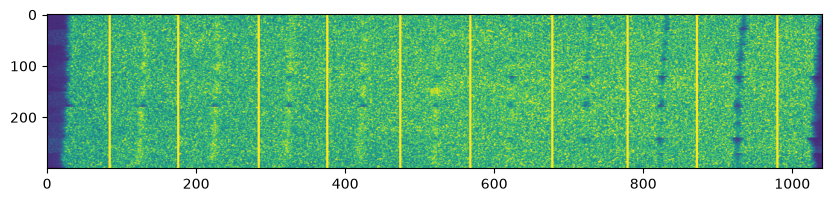

In [29]:
if RESET_ROIS:
    from utils.recover_core_lib import *

    points = []
    num_points = 0

    frame_recording, times = capture_N_frames(cam, 10, *cam.get_im_size()[::-1])
    raw_frame = frame_recording[-1].copy().astype(np.float32)

    # 2. Apply Log Transform: I_out = log(1 + I_in)
    image_log = np.log1p(raw_frame)

    # 3. Normalize the log image to 0-255 range for display (uint8)
    image = cv2.normalize(image_log, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    min_height = 20
    h, w = image.shape
    if h < min_height:
        repeat_factor = math.ceil(min_height / h)
        image = np.repeat(image, repeat_factor, axis=0)

    # Rename to avoid overwriting the row points
    selected_column_points = get_points_from_image(image, run_opt_recovery['N_vert_ROIs'])

    for x, y in selected_column_points:
        cv2.line(image, (x, 0), (x, image.shape[0]), 255, 2)

    plt.figure(figsize=(10, 2))
    plt.imshow(image, aspect='auto')
    plt.show()

In [30]:
if 'run_opt_multiROIs' in run_opt:
    run_opt_multiROIs = run_opt['run_opt_multiROIs']
else: # runs in manual mode
    print('running manually')
    # run_opt_multiROIs = {}
    run_opt_multiROIs['N_ROIs'] = N_ROI_ROWS
    run_opt_multiROIs['ROI_height'] = ROI_ROW_HEIGHT

print(run_opt_multiROIs)

running manually
{'N_ROIs': 10, 'ROI_height': 30, 'total_image_height': 300, 'global_ROI': (432, 0, 1040, 300), 'selected_row_points': [(521, 95), (811, 195), (811, 302), (813, 400), (917, 484), (918, 611), (908, 697), (909, 796), (911, 891), (902, 1003)], 'ROI_list': [(80, 110), (180, 210), (288, 318), (386, 416), (470, 500), (596, 626), (682, 712), (782, 812), (876, 906), (988, 1018)]}


## Final ROI Preview

In [31]:
import matplotlib.patches as patches

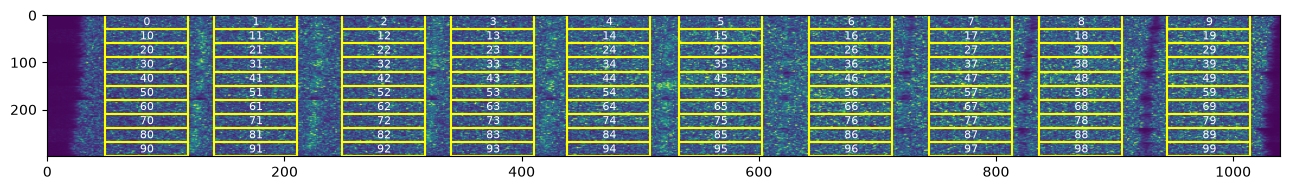

In [32]:
run_opt_recovery['N_vert_ROI_width'] = ROI_COLUMN_WIDTH

if RESET_ROIS:
    ROIs = []
    for row in range(run_opt_multiROIs['N_ROIs']):
        for col in range(run_opt_recovery['N_vert_ROIs']):
            x = selected_column_points[col][0] - run_opt_recovery['N_vert_ROI_width'] // 2
            y = row * run_opt_multiROIs['ROI_height']
            w = run_opt_recovery['N_vert_ROI_width']
            h = run_opt_multiROIs['ROI_height']
            ROIs.append((x, y, w, h))

    # manual change
    if 0:
        ROIs = ROIs[6:]
        ROIs.append((385 - run_opt_recovery['N_vert_ROI_width'] // 2, 0, w, h))

    run_opt_multiROIs['ROIs'] = ROIs

    # 1. Get the clean image (Do not draw cv2 rectangles on it)
    frame_show = stretch_contrast(frame_recording[5].copy())

    # 2. Setup the plot
    fig, ax = plt.subplots(figsize=(13, 2))
    ax.imshow(frame_show, aspect='auto')

    # 3. Add Vector Rectangles and Text on top
    for i, (x, y, w, h) in enumerate(run_opt_multiROIs['ROIs']):
        # Create the rectangle patch
        # (x - 0.5, y - 0.5) aligns the border exactly around the pixels
        rect = patches.Rectangle((x - 0.5, y - 0.5), w, h,
                                linewidth=1.5,      # Fixed screen width (remains thin)
                                edgecolor='yellow', # Color
                                facecolor='none')   # Transparent center

        # Add the rectangle to the plot
        ax.add_patch(rect)

        # Add the text label
        # Calculating center for the text position
        center_x = x + w / 2
        center_y = y + h / 2
        ax.text(center_x, center_y, str(i),
                color='white', fontsize=8,
                ha='center', va='center')

    plt.tight_layout()
    plt.show()

In [33]:
RESET_ROIS = False

## Set high frame rate for capturing

In [34]:
run_opt['cam_params']['camera_FPS'] = FPS
run_opt['cam_params']['exposure']   = EXPOSURE # how much light we let in
run_opt['cam_params']['gain']       = GAIN # amplify the elctrical signal caused by the photons

cam.set_frame_rate(run_opt['cam_params']['camera_FPS'])
cam.set_exposure(run_opt['cam_params']['exposure'])
cam.set_gain(run_opt['cam_params']['gain'])

print(f'ROI = {cam.get_global_roi()}')
print('Image height = {:} [px]'.format(cam.grabber.stream.get('Height')))
print(f'frame rate  = {cam.get_frame_rate()} [FPS]')
print(f'exposure  = {cam.get_exposure()} [us]')
print(f'max frame rate = {cam.get_max_frame_rate()} [Hz]')

if 1:
    run_opt['cam_params']['get_global_roi'] = cam.get_global_roi()
    run_opt['cam_params']['get_frame_rate'] = cam.get_frame_rate()
    run_opt['cam_params']['get_max_frame_rate'] = cam.get_max_frame_rate()
    run_opt['cam_params']['get_exposure'] = cam.get_exposure()

ROI = (432, 0, 1040, 300)
Image height = 300 [px]
frame rate  = 2500 [FPS]
exposure  = 60 [us]
max frame rate = 7287 [Hz]


In [35]:
# makes it faster to capture/send frames
cam.set_buffer_part_count(BUFFER_PART_COUNT)

# 4. Setup Speakers

In [36]:
import sounddevice as sd
import soundfile as sf
import numpy as np
import os

In [37]:
# add repo root (for utils) and src/data (for image, vibrate) to sys.path
import sys
from pathlib import Path
for p in (Path.cwd().parent, Path.cwd() / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
from utils.io_utils import load

In [38]:
# List devices
# our devices are Line Out (UltraLite-mk5) Windows WASAPI
# we do not use Windows DirectSound
print(sd.query_devices())
print(sd.query_hostapis())  # confirm ASIO is listed #todo: why??

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Line In 7-8 (UltraLite-mk5), MME (2 in, 0 out)
   2 Line In 5-6 (UltraLite-mk5), MME (2 in, 0 out)
   3 Mic/Line/Inst In 1-2 (UltraLite, MME (2 in, 0 out)
   4 Line In 3-4 (UltraLite-mk5), MME (2 in, 0 out)
   5 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  6 Main Out 1-2 (UltraLite-mk5), MME (0 in, 2 out)
   7 Realtek Digital Output (Realtek, MME (0 in, 2 out)
   8 Phones Out 1-2 (UltraLite-mk5), MME (0 in, 2 out)
   9 Line Out 7-8 (UltraLite-mk5), MME (0 in, 2 out)
  10 PL2792Q (NVIDIA High Definition, MME (0 in, 2 out)
  11 Line Out 5-6 (UltraLite-mk5), MME (0 in, 2 out)
  12 Line Out 9-10 (UltraLite-mk5), MME (0 in, 2 out)
  13 Line Out 3-4 (UltraLite-mk5), MME (0 in, 2 out)
  14 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
  15 Line In 7-8 (UltraLite-mk5), Windows DirectSound (2 in, 0 out)
  16 Line In 5-6 (UltraLite-mk5), Windows DirectSound (2 in, 0 out)
  17 Mic/Line/Inst In 1-2 (UltraLite-mk

In [39]:
def find_device(name_substring, hostapi_name="Windows WASAPI"):
    hostapis = sd.query_hostapis()
    target_hostapi = next(i for i, h in enumerate(hostapis) if h['name'] == hostapi_name)
    for idx, dev in enumerate(sd.query_devices()):
        if (dev['hostapi'] == target_hostapi
            and name_substring in dev['name']
            and dev['max_output_channels'] > 0):
            return idx
    raise ValueError(f"No output device matching {name_substring!r}")

In [40]:
_main   = find_device("Main Out 1-2")
_line34 = find_device("Line Out 3-4")
_line56 = find_device("Line Out 5-6")
_line78 = find_device("Line Out 7-8")
_line910 = find_device("Line Out 9-10")
_phones = find_device("Phones Out 1-2")

SPEAKERS = {
    1:  (_main,   0, False),
    2:  (_main,   1, False),
    3:  (_line34, 1, False),
    4:  (_line34, 0, False),
    5:  (_line56, 0, False),
    6:  (_line56, 1, False),
    7:  (_line78, 0, False),
    8:  (_line78, 1, False),
}

SPEAKERS

{1: (35, 0, False),
 2: (35, 1, False),
 3: (34, 1, False),
 4: (34, 0, False),
 5: (32, 0, False),
 6: (32, 1, False),
 7: (30, 0, False),
 8: (30, 1, False)}

In [41]:
device_info = sd.query_devices(list(SPEAKERS.values())[0][0])
SAMPLE_RATE = int(device_info['default_samplerate'])
print(f"Using sample rate: {SAMPLE_RATE}")

Using sample rate: 44100


In [42]:
_active_streams = []  # streams from the last non-blocking play_audio call; closed at the start of the next one

def play_audio(audio_input, speakers, wait=False):
    if isinstance(audio_input, (str, Path)):
        samples, _ = load(audio_input)  # (samples, sample_rate)
        audio = samples.astype(np.float32) / np.iinfo(samples.dtype).max
        if audio.ndim > 1: audio = audio.mean(axis=1)
    # if isinstance(audio_input, str):
    #     audio, _ = sf.read(audio_input, dtype="float32", always_2d=True)
    #     audio = audio.mean(axis=1)
    else:
        audio = audio_input

    if not isinstance(speakers, (list, tuple)):
        speakers = [speakers]

    # Group by device, build a stereo buffer per device
    device_bufs = {}
    for speaker in speakers:
        device_idx, channel_idx, is_mono = SPEAKERS[speaker]
        if device_idx not in device_bufs:
            device_bufs[device_idx] = np.zeros((len(audio), 2), dtype=np.float32)
        if is_mono:
            device_bufs[device_idx][:, 0] = device_bufs[device_idx][:, 1] = audio
        else:
            device_bufs[device_idx][:, channel_idx] = audio

    # close out streams left over from the previous non-blocking call, from this (main) thread —
    # never close a stream from inside its own callback, that deadlocks
    for s in _active_streams: s.close()
    _active_streams.clear()

    # Single device: one sd.play call
    if len(device_bufs) == 1:
        device_idx, buf = next(iter(device_bufs.items()))
        sd.play(buf, samplerate=SAMPLE_RATE, device=device_idx)
        if wait:
            sd.wait()
        return

    # Multiple devices: OutputStream with callbacks - PortAudio handles concurrency, no Python threads
    streams = []
    for device_idx, buf in device_bufs.items():
        pos = [0]
        def callback(outdata, frames, time_info, status, buf=buf, pos=pos):
            remaining = len(buf) - pos[0]
            chunk = min(frames, remaining)
            outdata[:chunk] = buf[pos[0]:pos[0] + chunk]
            if chunk < frames:
                outdata[chunk:] = 0
                raise sd.CallbackStop()
            pos[0] += chunk
        streams.append(sd.OutputStream(samplerate=SAMPLE_RATE, device=device_idx, channels=2, callback=callback))

    _active_streams.extend(streams)  # keep references alive so streams aren't garbage-collected mid-playback
    for s in streams:
        s.start()
    if wait:
        while any(s.active for s in streams):
            time.sleep(0.01)
        for s in streams: s.close()
        _active_streams.clear()

In [43]:
# play from three speakers at once, across different line outs
play_audio(AUDIO_DIR / 'audio.wav', [3,6,7], wait=True)

In [44]:
# play_audio(AUDIO_DIR / 'audio.wav', [1], wait=True)

In [45]:
# # play each speaker one by one
# for speaker in SPEAKERS.keys():
#     print(f'{speaker=}')
#     play_audio(AUDIO_PATH, [speaker])

# 5 Experiment Stages

In [46]:
# add repo root (for utils) and src/data (for image, vibrate) to sys.path
import sys
from pathlib import Path
for p in (Path.cwd().parent, Path.cwd() / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

In [47]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from utils.io_utils import copy, load, append, copy_to_sample
from utils.helpers import Timing, print_system_usage, setup_logger, logger
from utils.viz import preview, get_box_coverage_key
from vibrate import capture_vibrations, save_vibrations, process_vibrations, process_vibrations_2, warmup_pclk
from audio import load_audio_artifacts
from image import capture_overhead, save_overhead, process_overhead, make_overhead

In [48]:
def count_dirs(path): return sum(1 for path in path.iterdir() if path.is_dir()) if path.exists() else 0
def make_id(path): return f"{count_dirs(path):06d}"

In [49]:
def update_box_coverage(box_coverage:dict, sample_dir:str|Path=None, verbose:int=1):
    metadata = {'sample_id': ''} if sample_dir is None else {k: v for d in load(sample_dir / "metadata.jsonl") for k, v in d.items()}
    with Timing(f"[Sample {metadata['sample_id']}] box coverage: ", enabled=verbose>=2):
        if sample_dir is not None:
            mask = np.array(load(sample_dir / "image/02_smask.png"))

            # update box coverage
            key = get_box_coverage_key(metadata, mask)
            if key not in box_coverage: box_coverage[key] = {'mask': np.zeros(mask.shape), 'sample_ids': []}
            box_coverage[key]['mask'] += mask
            box_coverage[key]['sample_ids'].append(metadata['sample_id'])

            keys = [key]
        else:
            keys = box_coverage.keys()

    return box_coverage

In [50]:
def setup_experiment(experiment_dir:Path|str, audio_dir:Path|str, verbose:int=1, do_save:bool=True):
    """Bootstrap an experiment: logger, audio snapshot, sample/output dirs, box coverage."""
    experiment_dir, audio_dir = Path(experiment_dir), Path(audio_dir)
    is_new = not experiment_dir.exists()

    # logger (setup_logger mkdirs experiment_dir and creates logs.md)
    setup_logger(experiment_dir, verbose=verbose, do_save=do_save)

    # snapshot the audio into the experiment so it is self-contained; re-synced on every call
    # (skipped only when audio_dir already IS the in-experiment copy, e.g. a rerun that fed the
    # previous return value back in) so a regenerated/edited audio_dir is always picked up
    local_audio_dir = experiment_dir / audio_dir.parent.name / audio_dir.name
    if local_audio_dir.resolve() != audio_dir.resolve(): copy(audio_dir, local_audio_dir, do_save)
    if is_new: logger.info(f"initialized new experiment at {experiment_dir} (copied {audio_dir.name})")
    if not local_audio_dir.exists(): local_audio_dir = audio_dir  # do_save=False dry run: keep using the original

    # dirs + box coverage
    base_sample_dir, base_output_dir = experiment_dir / 'samples', experiment_dir / 'images'
    for p in (base_sample_dir, base_output_dir): p.mkdir(parents=True, exist_ok=True)
    box_coverage = {}
    for sample_dir in sorted(base_sample_dir.iterdir()):
        if (sample_dir / 'metadata.jsonl').exists():
            box_coverage = update_box_coverage(box_coverage, sample_dir, verbose)

    return local_audio_dir, base_sample_dir, base_output_dir, box_coverage

In [51]:
def run_experiment(obj_params, audio_params, segment_params, laser_camera_params, laser_grid_params, process_vibration_params, box_coverage, cam, overhead_cam, capture_image_fxn, play_audio_fxn, capture_n_frames_fxn, experiment_dir, base_output_dir, base_sample_dir, vibrate:bool=True, verbose: int = 1, do_save: bool = True):
    # setup
    output_id = make_id(base_output_dir)
    output_dir = base_output_dir / output_id
    is_empty_box = obj_params['n_objects'] == 0
    speakers_list = sp if isinstance(sp := audio_params.pop('speakers_list'), list) else [sp]
    sample_start = int(make_id(base_sample_dir))
    sample_end = sample_start + len(speakers_list) - 1
    header = f"Image {int(output_id)}, Samples [{sample_start},{sample_end}]"

    # record metadata
    metadata = obj_params | segment_params | laser_camera_params | laser_grid_params | process_vibration_params | dict(output_dir=str(output_dir), output_id=output_id, is_empty_box=is_empty_box)
    append([{k: v} for k, v in metadata.items()], output_dir / 'metadata.jsonl', do_save)

    cloud_threads = []

    with Timing(f'[output {output_id}] total: ', enter=f'[output {output_id}] start', enabled=verbose >= 1):
        # capture, process, save, and visualize overhead image
        raw_overhead = capture_overhead(overhead_cam, capture_image_fxn, output_dir, do_save=do_save)
        save_overhead(raw_overhead, output_dir, do_save=do_save)
        overhead_scored, result = process_overhead(raw_overhead, output_dir, **segment_params['resize_params'], objects=obj_params['objects'],
                                                   prompts=segment_params['prompts'], is_empty_box=is_empty_box,
                                                   segment_scale=segment_params['segment_scale'], verbose=verbose, do_save=do_save)
        orig = load_audio_artifacts(audio_params['audio_dir'])  # (samples, fs, freqs, fft, spec_freqs, spec_times, Sxx, max_freq), all precomputed on disk
        preview((result, overhead_scored, result['names'], *orig, header), 'plot_live_image')
        if not vibrate: return None, None

        # loop over all speakers
        sample_dirs = []
        for speakers in speakers_list:
            # setup
            sample_id = make_id(base_sample_dir)
            sample_dir = base_sample_dir / sample_id
            sample_dirs.append(sample_dir)
            print_system_usage(experiment_dir, label=f'[sample {sample_id}]', verbose=verbose)
            with Timing(f'[sample {sample_id}] total: ', enter=f'\n[sample {sample_id}] start', enabled=verbose >= 1):
                copy_to_sample(sample_dir, output_dir, audio_params['audio_dir'], speakers, do_save=do_save)            

                # capture vibrations
                raw_vibrations = capture_vibrations(cam, speakers, play_audio_fxn, capture_n_frames_fxn, audio_params['audio_dir'], sample_dir, laser_camera_params['height'], laser_camera_params['width'],
                                                    laser_camera_params['n_capture_seconds'], laser_camera_params['fps'], verbose=verbose, do_save=do_save)
                
                # visualize vibrations
                if verbose >= 1:
                    vib = process_vibrations_2(sample_dir, raw_vibrations, pclk_mode='sequential', do_save=do_save, verbose=verbose, cleanup_raw_vibrations=None, spectrogram_video=False, laser_idx=50, xy_idx=0)
                    sample_overhead = make_overhead(sample_dir, output_dir, speakers, verbose=verbose, do_save=do_save)
                    box_coverage = update_box_coverage(box_coverage, sample_dir, verbose)
                    preview((sample_overhead, raw_vibrations, box_coverage, sample_dir, result,
                             vib['freqs'], vib['fft'], vib['xy_idx'], vib['laser_idx'],
                             vib['recovered_audio'], vib['audio_sample_rate'],
                             vib['spec_freqs'], vib['spec_times'], vib['Sxx'], vib['max_freq'],
                             f'Speaker {speakers}, Image {int(output_id)}, Sample {int(sample_id)}'), 'plot_live_sample')

                # save vibrations on another thread so non-blocking
                t = threading.Thread(target=save_vibrations, args=(raw_vibrations, sample_dir, audio_params['audio_dir'], do_save, verbose), daemon=True)
                t.start()
                cloud_threads.append(t)
                logger.debug(f'[Sample {sample_id}] saving on thread {t.ident}')

        # block until we've saved all vibrations
        for t in cloud_threads: t.join()

    return sample_dirs, cloud_threads

In [52]:
RESIZE_PARAMS = {'cardboard': {"left": 0.1, "right": 0.7, "up": 0.21, "down": 0.78, "max_side": 256},
                 'taped-cardboard': {"left": 0.07, "right": 0.63, "up": 0.05, "down": 0.65, "max_side": 256},
                 'wood': {"left": 0.23, "right": 0.55, "up": 0.47, "down": 0.8, "max_side": 256},
                 'slat-wood': {"left": 0.2, "right": 0.55, "up": 0.2, "down": 0.8, "max_side": 256},
                 'metal': {"left": 0.21, "right": 0.54, "up": 0.66, "down": 0.86, "max_side": 256},
                 'shoebox': {"left": 0.21, "right": 0.56, "up": 0.44, "down": 0.82, "max_side": 256},
                 'plastic': {"left": 0.24, "right": 0.59, "up": 0.27, "down": 0.62, "max_side": 256},
                 'gastronorm': {"left": 0.05, "right": 0.7, "up": 0.1, "down": 0.82, "max_side": 256},
                 }
PROMPTS = {'cylinder': "Metal circle", 'bullet': 'Metal circle', 'cylinder-bullet-stack': 'Metal circle', 'cube': 'Black cube with straight edges',
           'green-cube': 'Green square', 'purple-cube': 'Purple square', 'red-cube': 'Red cube'}

In [53]:
1/0

ZeroDivisionError: division by zero

In [ ]:
# import sounddevice as sd, numpy as np, traceback

# sd.stop()                          # abort any stuck default-stream playback
# sd._terminate(); sd._initialize()  # rebuild PortAudio, drop leaked streams — variables untouched

# # quick single-device test straight to hardware (Line Out 3-4)
# idx = next(i for i,d in enumerate(sd.query_devices())
#            if 'Line Out 3-4' in d['name'] and d['max_output_channels']>0 and d['hostapi']==2)
# try:
#     t = np.linspace(0, 1, 22050, False); tone = 0.1*np.sin(2*np.pi*440*t)
#     sd.play(np.column_stack([tone, tone]).astype(np.float32), samplerate=44100, device=34, blocking=True)
#     print('OK — PortAudio healthy again on', idx)
# except Exception:
#     traceback.print_exc()


## audio

In [54]:
from argparse import Namespace

from data.audio import main
from utils.viz import preview

T_SEC = 1
T_START = 0.1
T_END = 0.1
FS = 44100
F_START = 50
F_END = 1000
n_capture_seconds = (T_SEC + T_START + T_END) + 0.1

audio_dir = Path(rf'C:\Users\eitanturok\good-vibrations\data\audio\chirp_{int(F_START)}_{int(F_END)}_{T_SEC}sec')

# run data/audio.py::main() for real -- generates+saves audio.wav, metadata.jsonl, fft.npz/png,
# spectrogram.npz/png, and the spectrogram.mp4 video, all under audio_dir
args = Namespace(T_sec=T_SEC, T_start=T_START, T_end=T_END, fs=FS, f_start=F_START, f_end=F_END, out_dir=audio_dir)
audio = main(args)

preview((audio_dir / 'audio.wav', FS), 'audio')

Already computed audio in C:\Users\eitanturok\good-vibrations\data\audio\chirp_50_1000_1sec


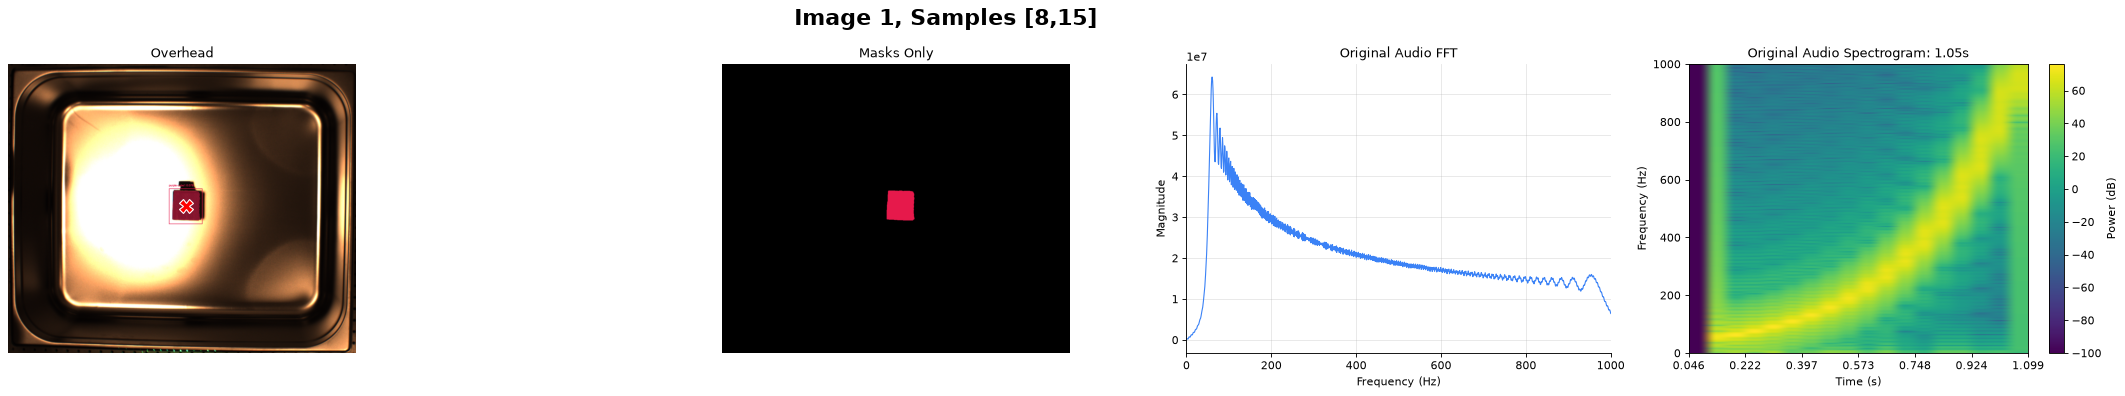

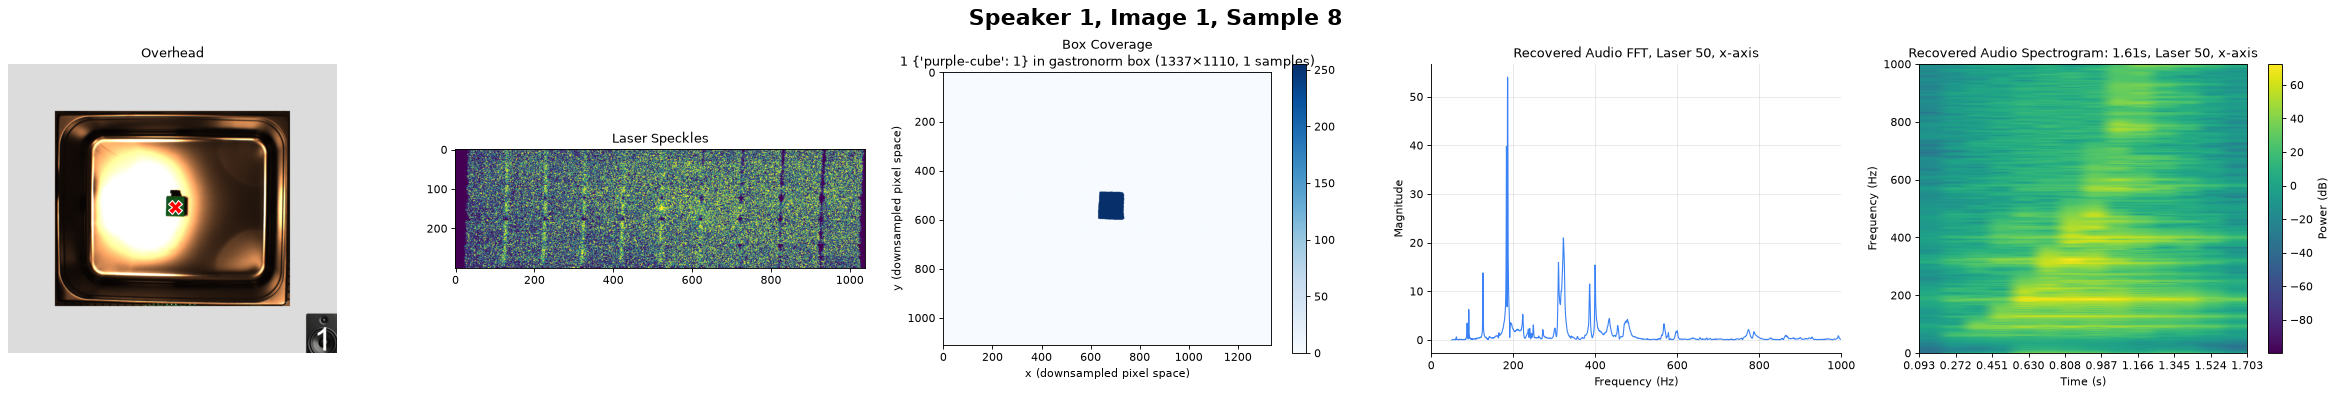

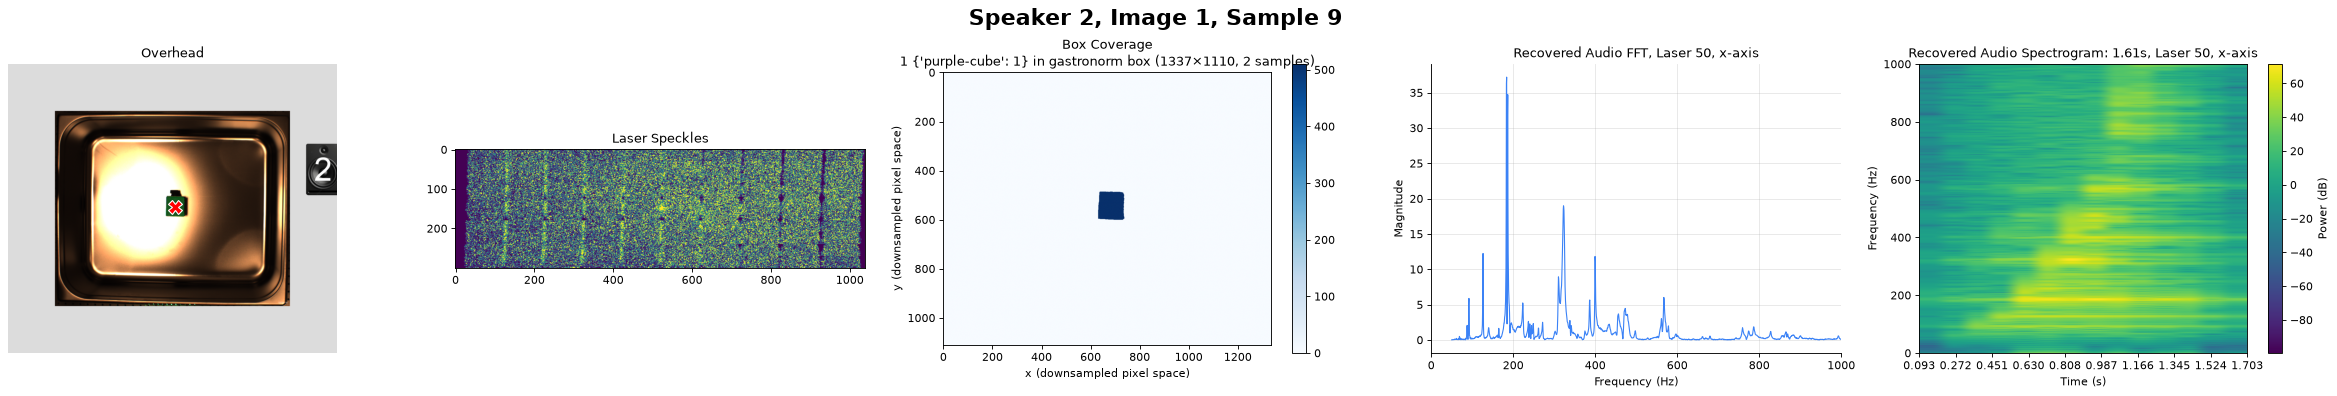

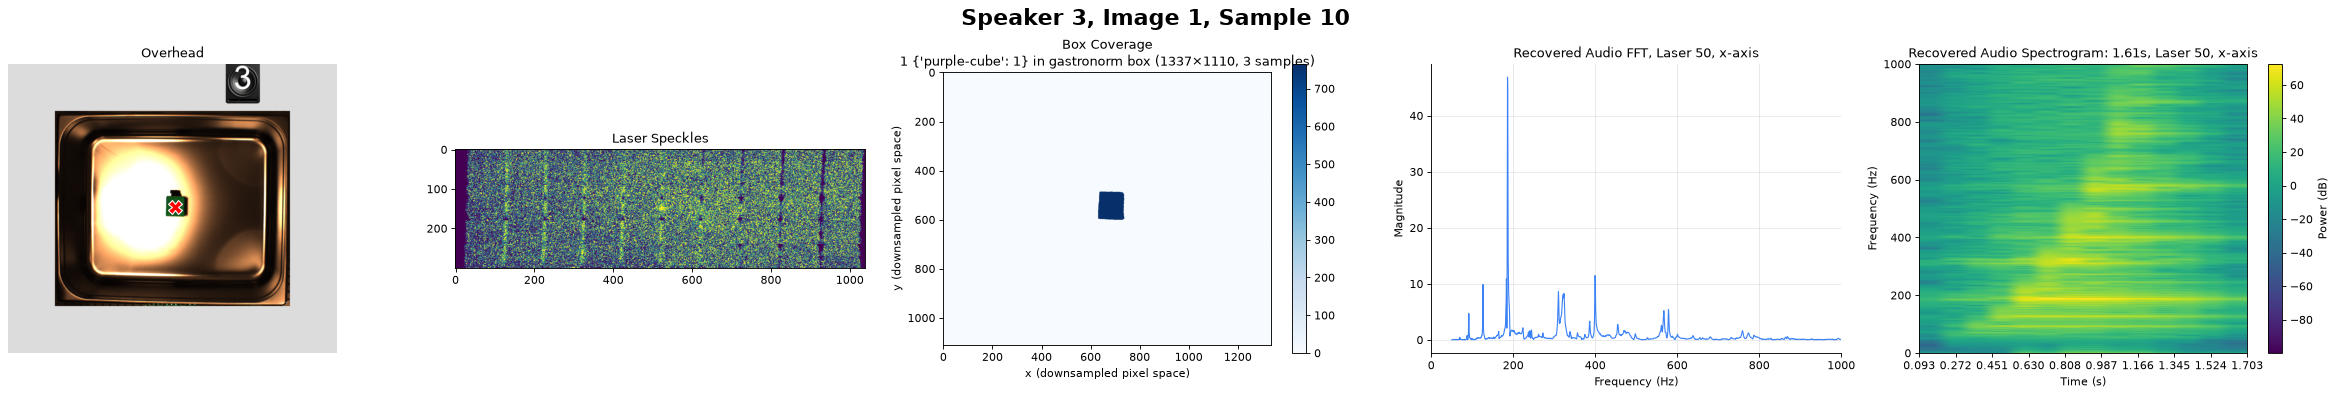

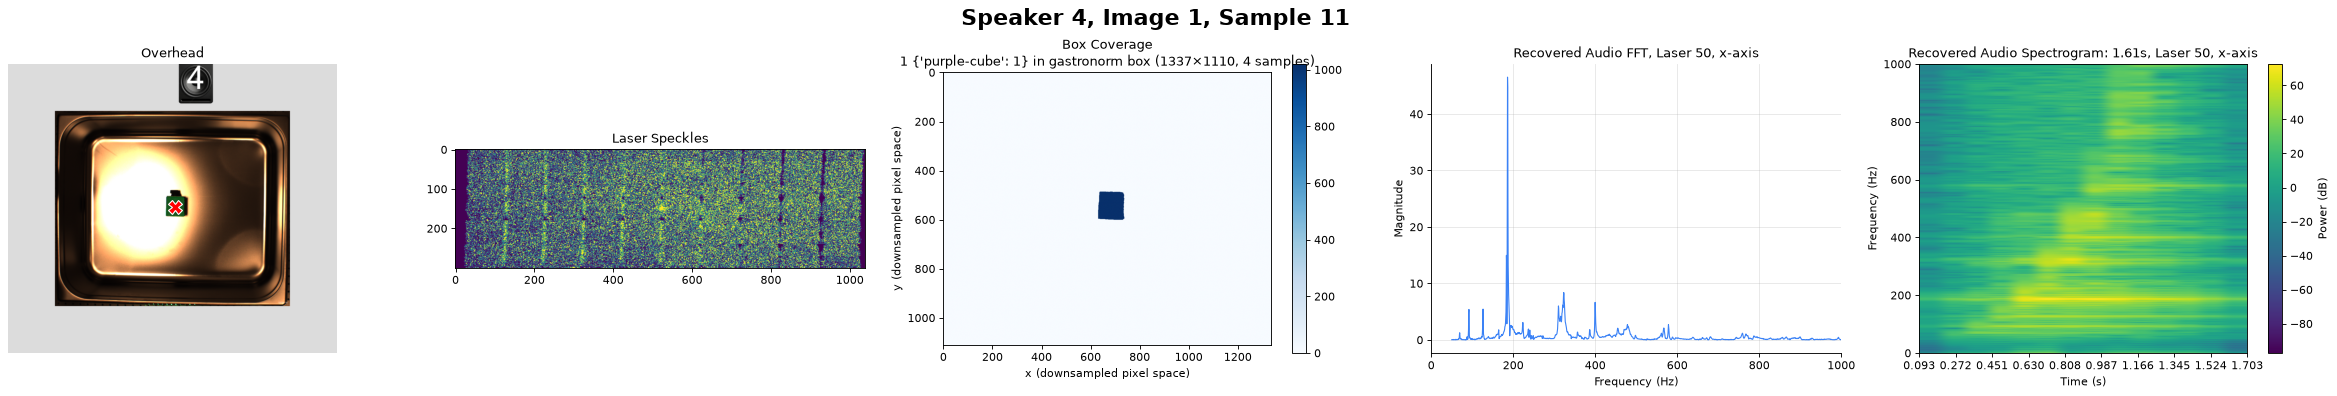

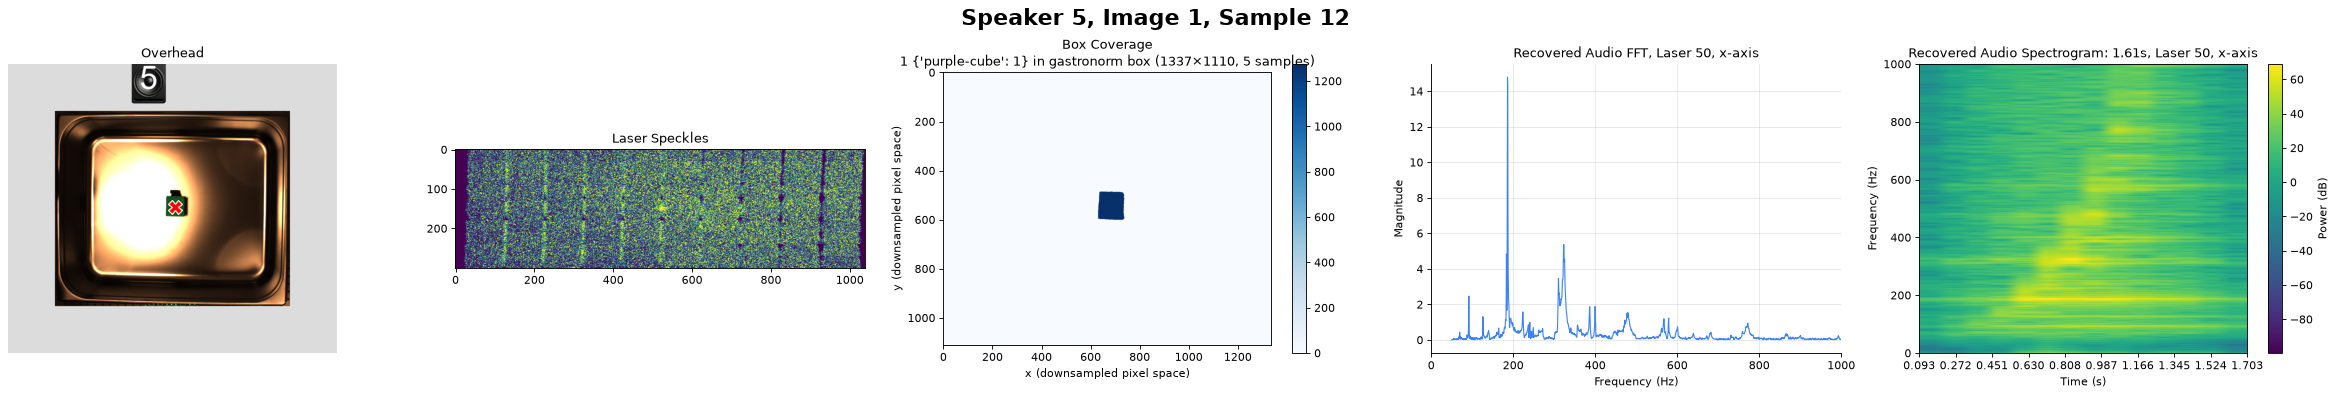

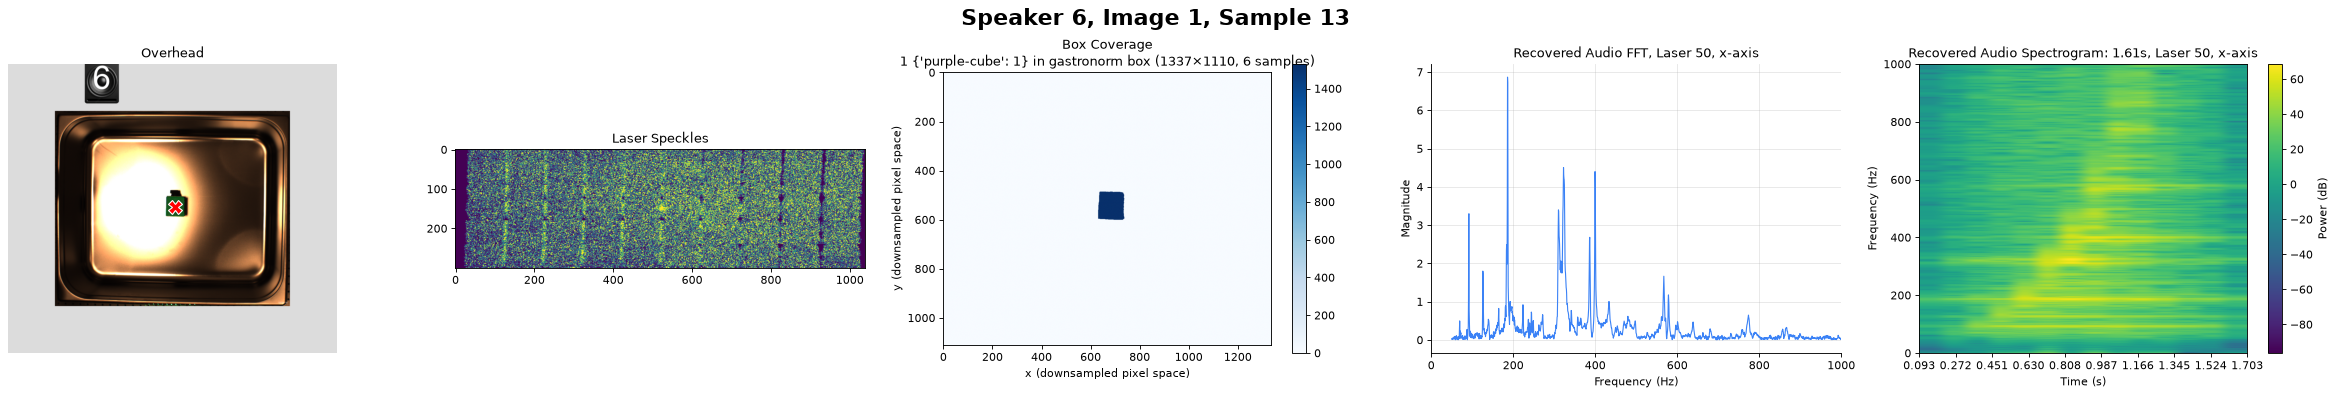

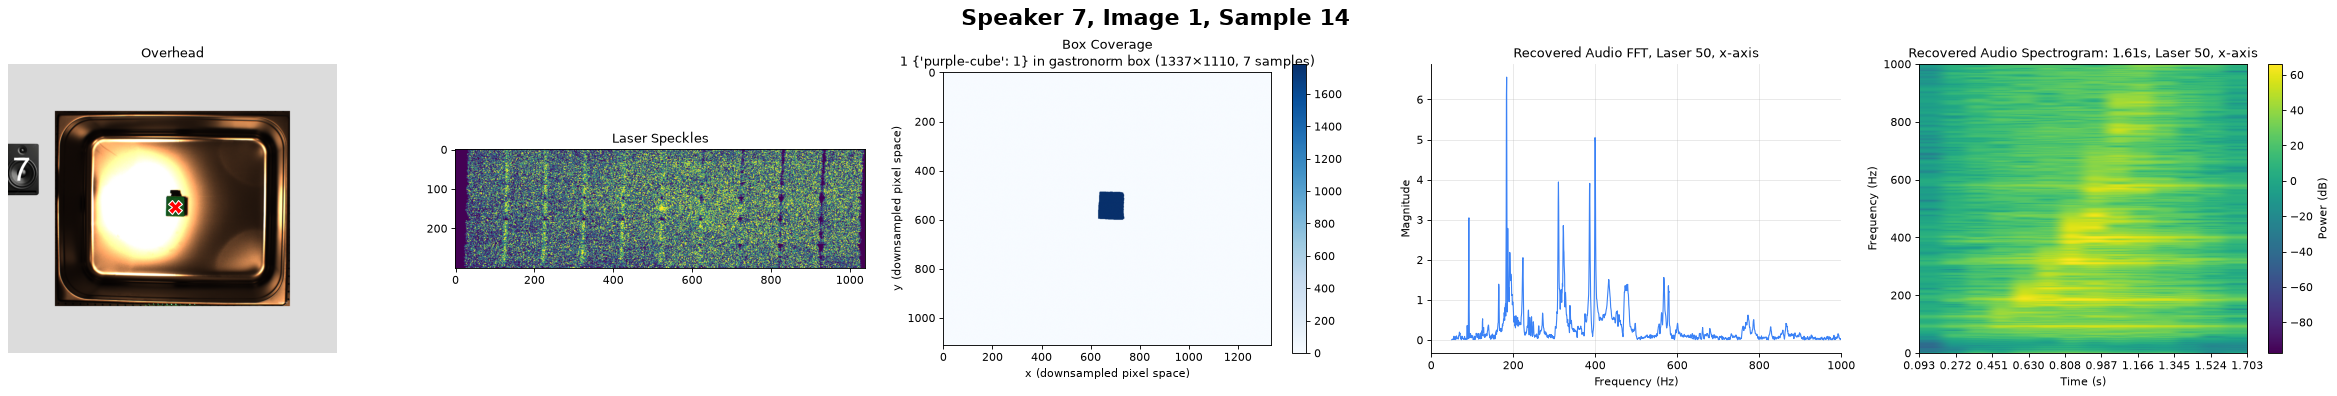

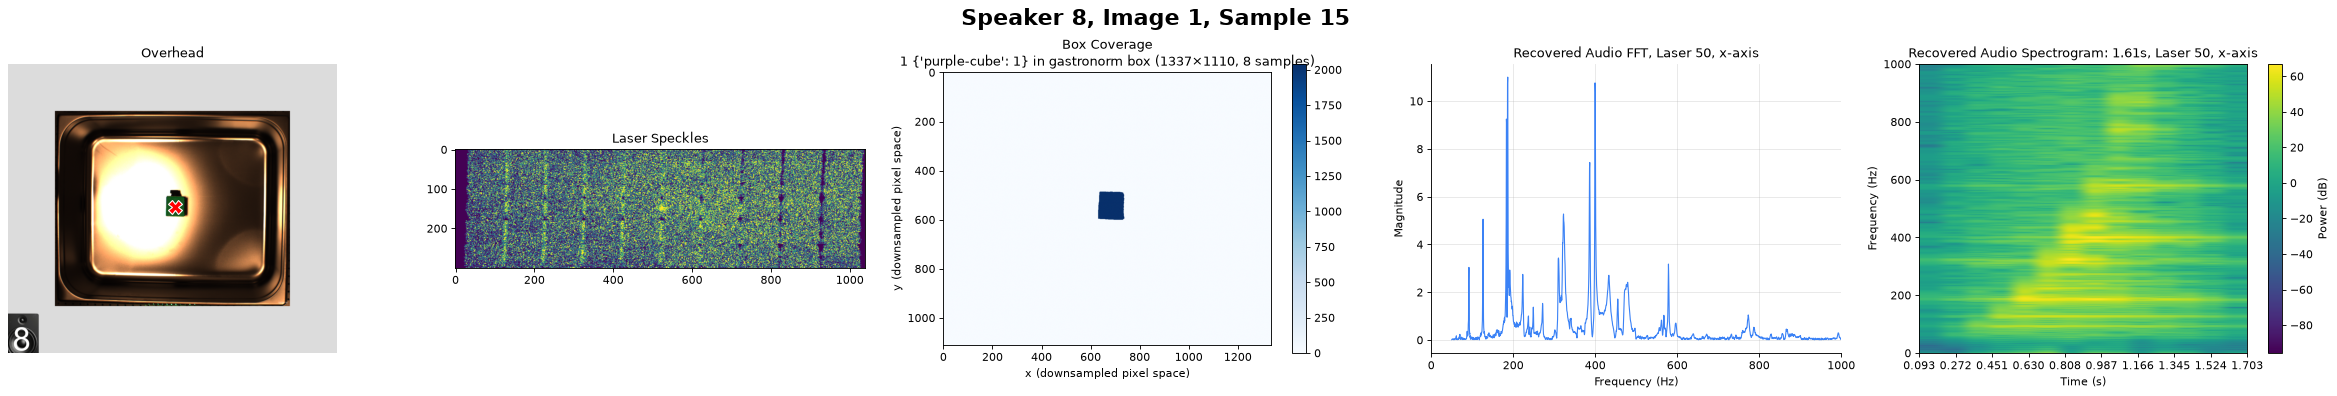

[WindowsPath('D:/eturok/experiment-26/samples/000008'), WindowsPath('D:/eturok/experiment-26/samples/000009'), WindowsPath('D:/eturok/experiment-26/samples/000010'), WindowsPath('D:/eturok/experiment-26/samples/000011'), WindowsPath('D:/eturok/experiment-26/samples/000012'), WindowsPath('D:/eturok/experiment-26/samples/000013'), WindowsPath('D:/eturok/experiment-26/samples/000014'), WindowsPath('D:/eturok/experiment-26/samples/000015')]


In [59]:
box = 'gastronorm'
experiment_dir = Path(r'D:/eturok/experiment-26')

EMPTY_BOX = False
objects = {'purple-cube': 1}
layout = 'purple-cube'
description = f"A green metal sitting on the floor of an closed {box} box from a bird's eye view."

speakers_list = [1, 2, 3, 4, 5, 6, 7, 8]
# speakers_list = [1]

verbose = 1
do_save = True
vibrate = True

# init experiment: logger, audio snapshot, sample/output dirs, box coverage
base_audio_dir, base_sample_dir, base_output_dir, box_coverage = setup_experiment(experiment_dir, audio_dir, verbose=verbose, do_save=do_save)
if vibrate: warmup_pclk(verbose=verbose)  # absorb ~4s cupy/cuFFT init here instead of on the first sample

# define params
resize_params = RESIZE_PARAMS[box]
prompts = {o: PROMPTS[o] for o in objects}
if EMPTY_BOX: objects, layout, description = {}, "empty-box", f"An empty open {box} box from a bird's eye view."

n_objects = sum(objects.values())
cam_h, cam_w = cam.get_im_size()[::-1]

# laser_grid_bounds tells us which of our 10x10 lasers actually hit the box
laser_grid_bounds = (0, 10, 0, 10) # (l, r, b, t) where l<=x<r, b<=y<t 
n_laser_rows, n_laser_cols = laser_grid_bounds[1] - laser_grid_bounds[0], laser_grid_bounds[3] - laser_grid_bounds[2]
n_lasers = n_laser_rows * n_laser_cols

obj_params = dict(objects=objects, n_objects=n_objects, box=box, layout=layout, description=description)
audio_params = dict(audio_dir=base_audio_dir, speakers_list=speakers_list, min_freq=50, max_freq=1000, audio_sample_rate=22050)
segment_params = dict(resize_params=resize_params, prompts=prompts, segment_scale=1)
laser_camera_params = dict(roi=run_opt_multiROIs['ROIs'], fps=FPS, n_capture_seconds=n_capture_seconds, height=cam_h, width=cam_w, run_opt=run_opt, run_opt_multiROIs=run_opt_multiROIs)
laser_grid_params = dict(laser_beam_splitter=(10, 10), laser_grid_bounds=laser_grid_bounds, n_lasers=n_lasers, n_laser_rows=n_laser_rows, n_laser_cols=n_laser_cols)
process_vibration_params = dict(patch_size=128, min_freq=50, max_freq=1000)

# run the experiment
output_id, start_sample, end_sample = int(make_id(base_output_dir)), int(make_id(base_sample_dir)), int(make_id(base_sample_dir)) + len(audio_params['speakers_list']) - 1
label = f"[output {output_id:06d}, samples {start_sample:06d}-{end_sample:06d}]"
with Timing(f"{label} total time: ", enter=f"{label} start", enabled=verbose>=1):
    sample_dirs, cloud_threads = run_experiment(obj_params, audio_params, segment_params, laser_camera_params, laser_grid_params, process_vibration_params, box_coverage, cam, overhead_cam, 
                                                capture_image, play_audio, capture_N_frames, experiment_dir, base_output_dir, base_sample_dir, vibrate=vibrate, verbose=verbose, do_save=do_save)
    print_system_usage(experiment_dir, label=f'[output {output_id}]', verbose=verbose)
    plt.close()
    print(sample_dirs)

In [ ]:
def preview_sample(sample_id:int):
    sample_dir = base_sample_dir / f'{sample_id:06d}'
    sample_metadata = {k: v for d in load(sample_dir / 'metadata.jsonl') for k, v in d.items()}
    output_dir, speaker = Path(sample_metadata['output_dir']), sample_metadata['speaker']

    # result isn't persisted as a dict, so rebuild it from what process_overhead saved to output_dir/smasks/
    records = load(output_dir / 'smasks/metadata.jsonl')
    names = [r['name'] for r in records]
    result = {'names': names, 'scores': np.array([r['score'] for r in records]),
            'boxes': np.stack([np.array(r['box']) for r in records]),
            'masks': np.stack([load(output_dir / f'smasks/{name}.npy').astype(bool) for name in names])}

    raw_vibrations = load(sample_dir / 'vibration/00_raw_vibrations.npy')
    vib = process_vibrations_2(sample_dir, raw_vibrations, pclk_mode='batched_optimized', pclk_batch_size=256, do_save=False, verbose=1, cleanup_raw_vibrations=None, spectrogram_video=False, laser_idx=50, xy_idx=0)
    sample_overhead = make_overhead(sample_dir, output_dir, speaker, verbose=1, do_save=False)

    preview((sample_overhead, raw_vibrations, box_coverage, sample_dir, result,
            vib['freqs'], vib['fft'], vib['xy_idx'], vib['laser_idx'],
            vib['recovered_audio'], vib['audio_sample_rate'],
            vib['spec_freqs'], vib['spec_times'], vib['Sxx'], vib['max_freq'],
            f'Sample {sample_id}'), 'plot_live_sample')
    

    preview(((audio, FS), (vib['recovered_audio'], vib['audio_sample_rate']), vib['max_freq']), 'audio_comparison')
    

preview_sample(0)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\eturok\\experiment-27\\samples\\000000\\metadata.jsonl'